# Batching raw ultrasound data with `zea.Dataloader`

`zea.Dataloader` turns a folder of zea files into a batched, shuffled, multi-threaded stream of
samples, ready for a training loop. It is built on [Google Grain](https://github.com/google/grain).

We'll be using channel data (`raw_data`) in this notebook. We'll stream from the
[TU/e carotid dataset](https://huggingface.co/datasets/zeahub/zea-carotid-2023) on the Hugging Face
Hub. `zea.File` streams and caches only the HDF5 chunks a sample actually touches.

See the [Dataloader API reference](../../_autosummary/zea.data.dataloader.rst) for the full set of
arguments, and the [zea.data overview](../../_autosummary/zea.data.rst) for how
`zea.File`, `zea.Dataset`, and `zea.Dataloader` relate.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_dataloader_example.ipynb)
&nbsp;
[![View on GitHub](https://img.shields.io/badge/GitHub-View%20Source-blue?logo=github)](https://github.com/tue-bmd/zea/blob/main/docs/source/notebooks/data/zea_dataloader_example.ipynb)
&nbsp;
[![Hugging Face dataset](https://img.shields.io/badge/Hugging%20Face-Dataset-yellow?logo=huggingface)](https://huggingface.co/datasets/zeahub/zea-carotid-2023)

‼️ **Important:** This notebook is optimized for **GPU/TPU**. Code execution on a **CPU** may be very slow.

If you are running in Colab, please enable a hardware accelerator via:

**Runtime → Change runtime type → Hardware accelerator → GPU/TPU** 🚀.

In [1]:
%%capture
%pip install zea

In [2]:
file_paths = [
    "hf://zeahub/zea-carotid-2023/data/2_long_2cm_0000.hdf5",
    "hf://zeahub/zea-carotid-2023/data/3_long_2cm_L_0000.hdf5",
    "hf://zeahub/zea-carotid-2023/data/3_cross_2cm_L_0000.hdf5",
]
plane_waves = list(range(128, 149))  # the plane-wave transmits of each frame

In [3]:
import os

os.environ["KERAS_BACKEND"] = "jax"

In [4]:
import zea
from zea.visualize import plot_image_grid, set_mpl_style

zea: Using backend 'jax'


In [5]:
zea.init_device(verbose=False)
set_mpl_style()

## Batching raw channel data

Point `zea.Dataloader` at the file(s) or folder(s), and give it the key to read. Each carotid file holds
`raw_data` of shape `(150, 149, 2176, 128, 1)` — `(n_frames, n_tx, n_ax, n_el, n_ch)` — where every
frame is a sweep of 128 focused scanlines followed by 21 plane waves. `axis_selections` loads only
the plane waves, saving the memory and I/O of the scanlines we don't need here.

In [6]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=2,
    limit_n_frames=1,  # keeps this notebook fast
    axis_selections={1: plane_waves},
)

print("batches:", len(loader))

batch = next(iter(loader))
print("first batch:", batch.shape, batch.dtype)

batches: 2
first batch: (2, 21, 2176, 128, 1) int16


## Temporal blocks

Instead of loading (a batch of) single frames, one can also load batches of (consecutive) frames.

Set `n_frames > 1` to get blocks of frames per sample. For raw data, put the frame axis first with `frame_axis=0` so samples keep the `(n_frames, n_tx, n_ax, n_el, n_ch)` layout of the file.

**More options**
- `frame_index_stride` subsamples within a block
- `overlapping_blocks=True` slides the block by one frame instead of `n_frames`.

In [7]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=None,  # no batching: one sample at a time
    n_frames=2,
    frame_axis=0,
    axis_selections={1: plane_waves},
    shuffle=False,
)

# We're not iterating this dataloader to avoid (pre)fetching all frames.
print("blocks:", len(loader))
print("sample shape:", loader.shape)

blocks: 225
sample shape: (2, 21, 2176, 128, 1)


## Metadata and file selection

A zea file carries **much more** than its data array!

We can use `return_metadata` to load any metadata fields we want, and `file_filter` to drop files that don't match a condition. Both take **dotted paths** into the file: a path may point at a single field (`"scan.sound_speed"`) or at a whole group (`"metadata.subject"`), in which case the full group is returned.

The returned metadata mirrors the [zea file spec](../../_autosummary/zea.data.spec.rst).


zea: DEBUG file_filter excluded 'hf://zeahub/zea-carotid-2023/data/2_long_2cm_0000.hdf5'.


zea: file_filter kept 2/3 files (1 removed).
samples after filtering: 4
carotid artery | subject 3 (human) | Verasonics Vantage 256 | c = 1540.0 m/s


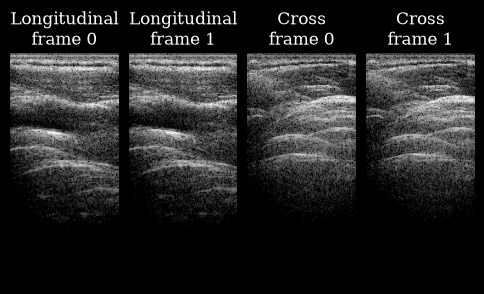

In [8]:
loader = zea.Dataloader(
    file_paths,
    key="data/raw_data",
    batch_size=None,
    limit_n_frames=2,
    axis_selections={1: plane_waves},
    shuffle=False,
    file_filter={"metadata.subject.id": "3"},
    return_metadata=[
        "metadata.subject",
        "metadata.annotations",
        "scan.sound_speed",
        "scan.time_to_next_transmit",
        "probe.probe_geometry",
        "us_machine",
    ],
)


def _to_display(x):
    x = zea.func.envelope_detect(x.astype("float32"), axis=-3)[::8]
    x = zea.func.normalize(x, (0, 1))
    return zea.func.log_compress(x)


images, titles = [], []
for sample, metadata in loader:
    images.append(_to_display(sample[0]))  # select tx 0
    annotations, file = metadata["metadata"]["annotations"], metadata["file"]
    titles.append(f"{annotations['view'].split()[0]}\nframe {file['indices'][0]}")

subject = metadata["metadata"]["subject"]
print("samples after filtering:", len(loader))
print(
    f"{annotations['anatomy']} | subject {subject['id']} ({subject['type']}) "
    f"| {metadata['us_machine']} | c = {metadata['scan']['sound_speed']} m/s"
)

fig, _ = plot_image_grid(
    images, ncols=4, vmin=-50, vmax=0, titles=titles, figsize=(8, 3), cmap="gray"
)